**VIX in the one-factor Bergomi model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
from bergomi import OneFactorBergomiModel, get_params_one_bergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import relative_error

sns.set_theme(context="talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)

# Global settings
SEED = 1234
COLORS = sns.color_palette("tab10")
SAVEFIG = True

In [3]:
mats = {"1M": 1.0 / 12.0, "3M": 3.0 / 12.0, "6M": 6.0 / 12.0}

# Single case

## VIX implied volatility

In [4]:
# model parameters
id = 2
params, xi0 = get_params_one_bergomi(id=id, opt="single")
onebergomi = OneFactorBergomiModel(xi0=xi0, params=params)
onebergomi

OneFactorBergomiModel with parameters:
w=8.0, k=10, rho=-0.5, s0=1.0

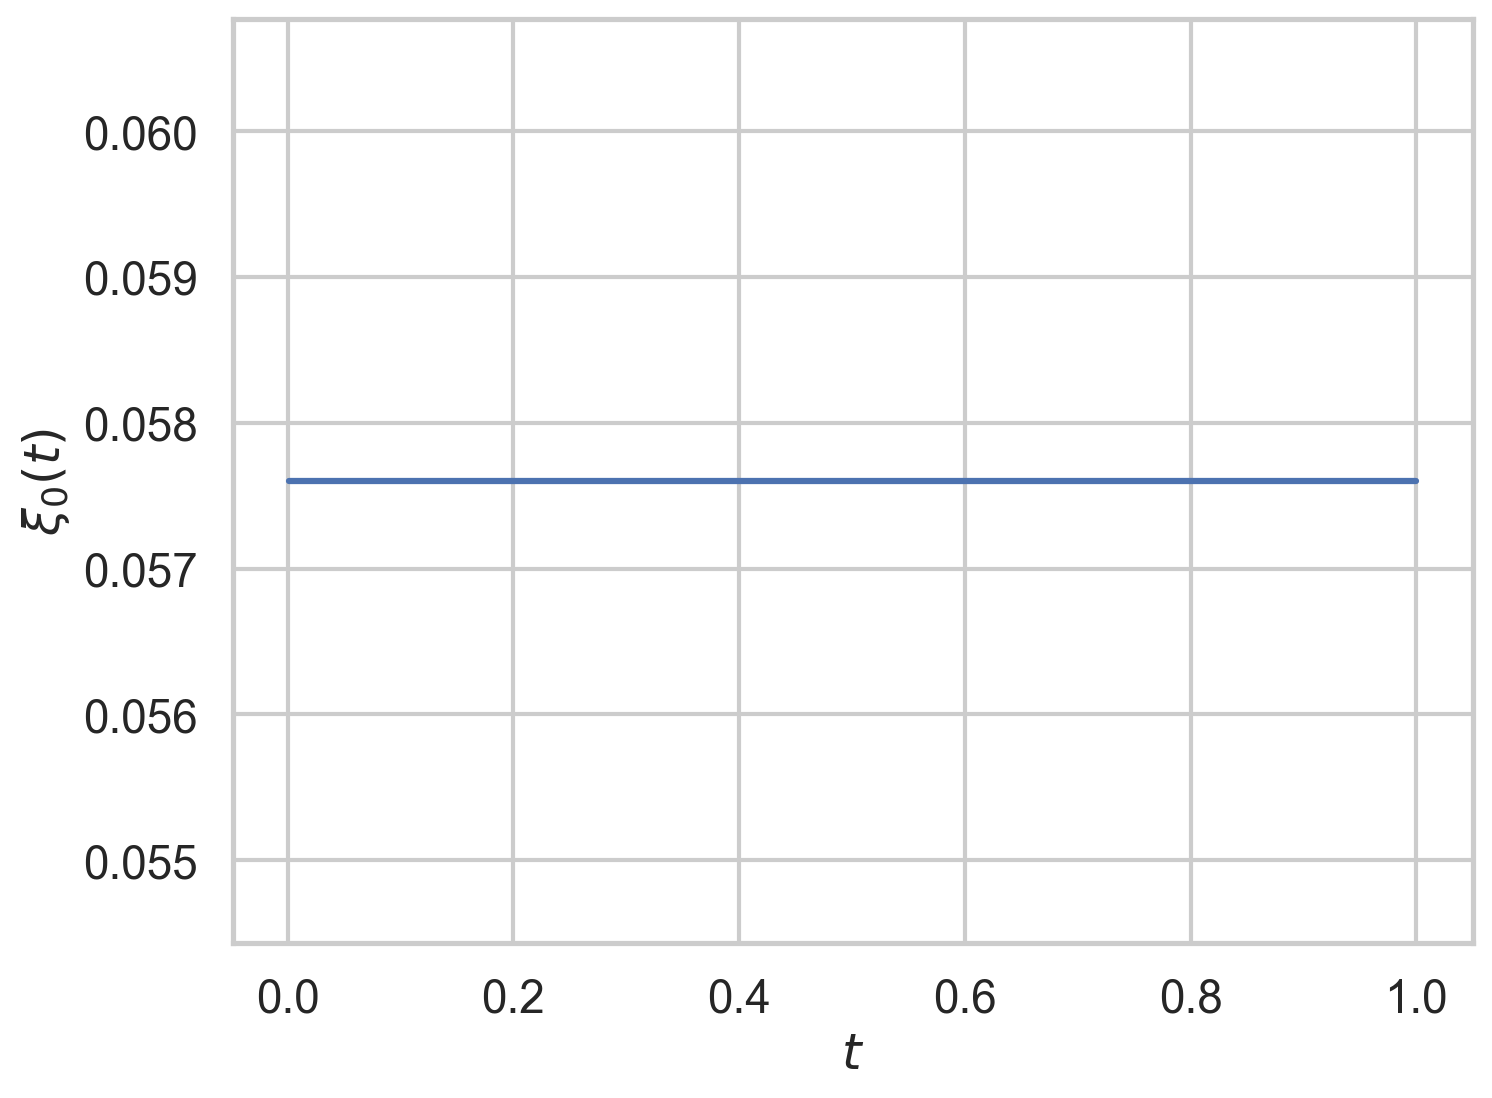

In [5]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, onebergomi.xi0(ts))
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [6]:
# log moneyness
ks = np.linspace(-0.1, 0.4, 10)
n_quad = 120

In [7]:
# VIX implied volatilities via quadrature
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad)
    for month, T in mats.items()
}

In [8]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: onebergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [9]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: onebergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

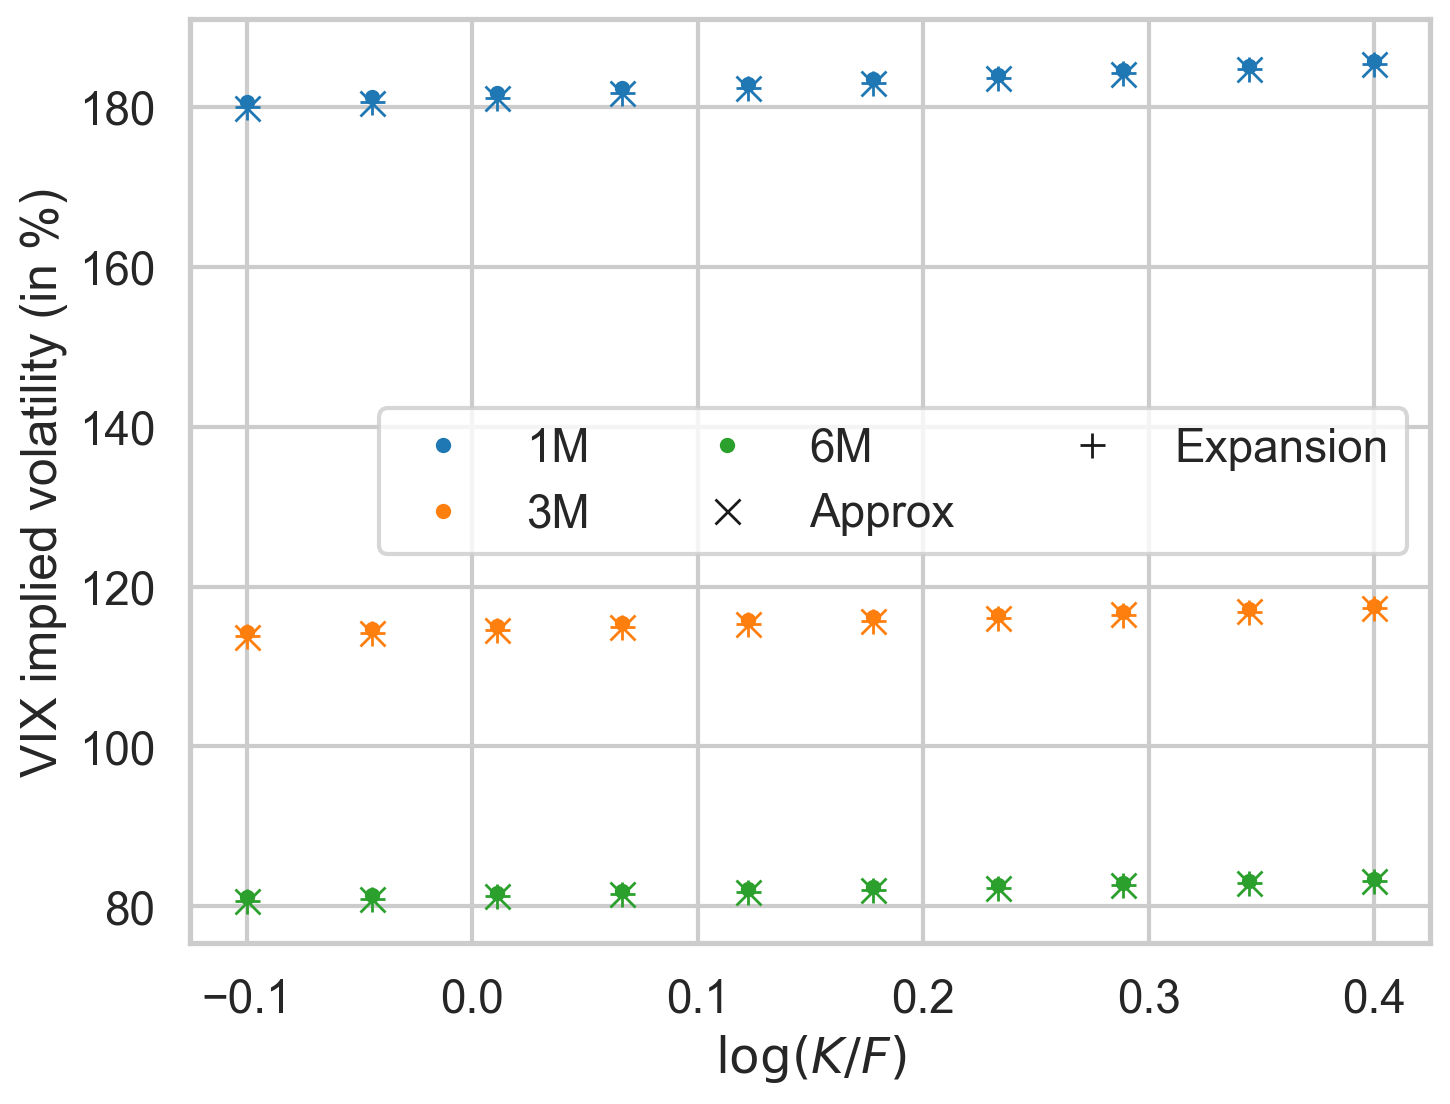

In [ ]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 1e2 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 1e2 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 1e2 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$\log(K/F)$")
ax.set_ylabel("VIX implied volatility (in %)")
ax.legend(ncol=3)
if SAVEFIG:
    fig.savefig(f"figures/vix_one_bergomi_{id}.pdf", bbox_inches="tight")
plt.show()

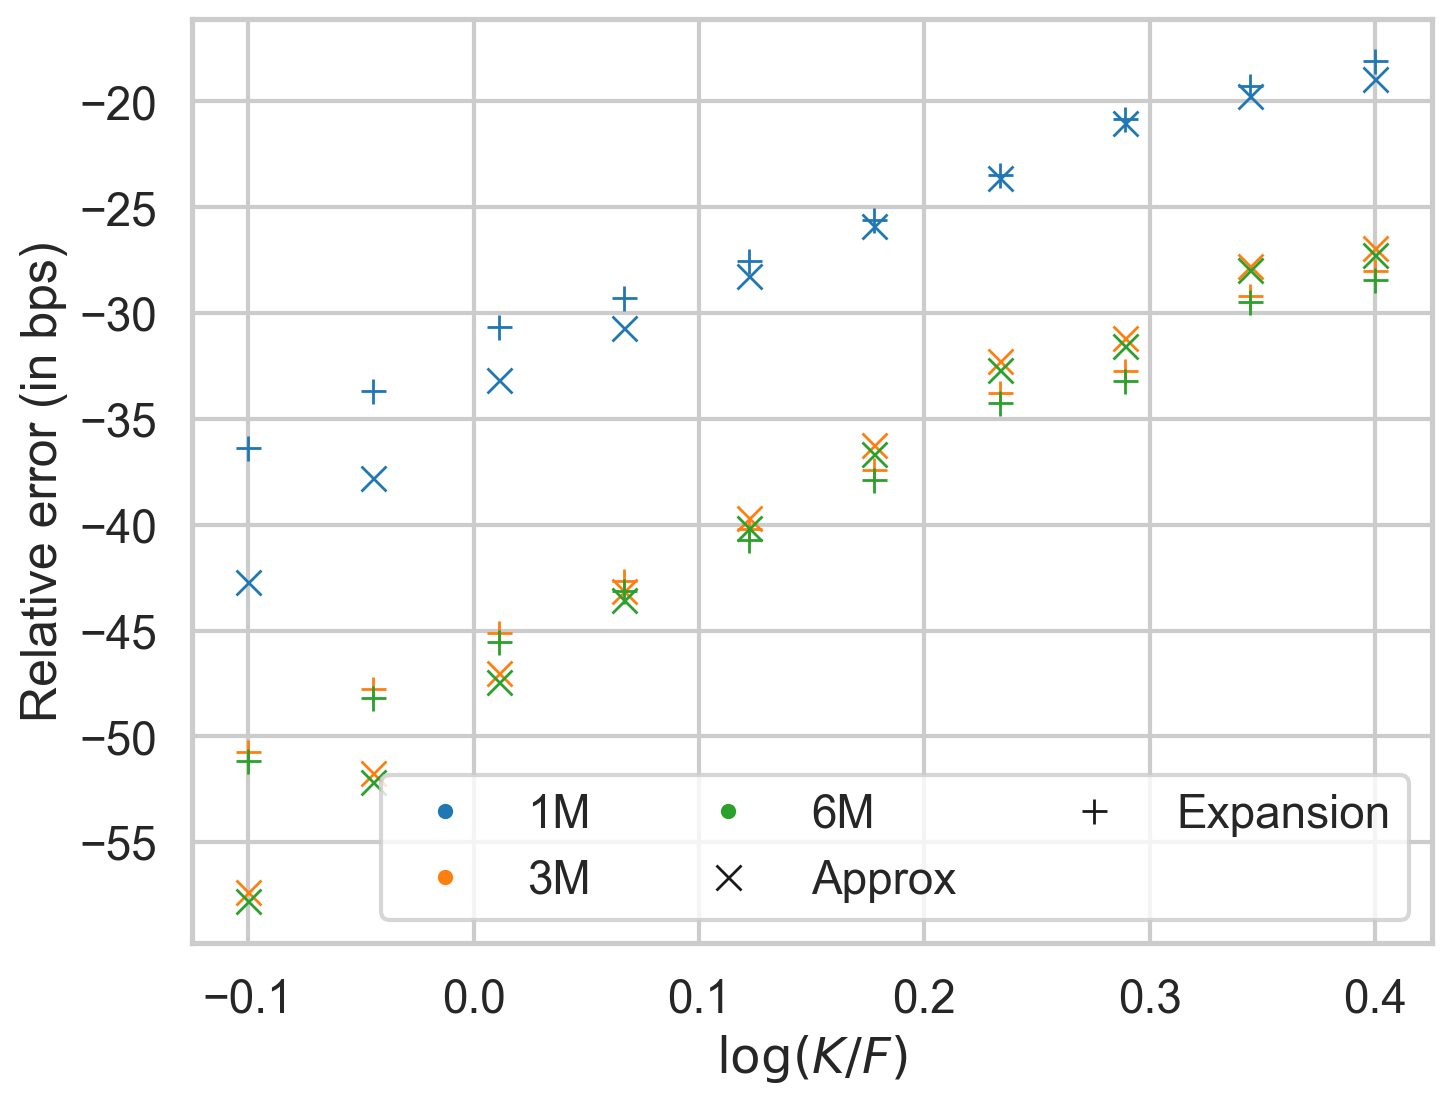

In [22]:
# relative errors
rel_error_approx = [
    relative_error(true_value=impvol_vix[month], approx_value=impvol_vix_approx[month])
    for month in mats
]
rel_error_expansion = [
    relative_error(
        true_value=impvol_vix[month], approx_value=impvol_vix_expansion[month]
    )
    for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 1e4 * rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, 1e4 * rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$\log(K/F)$")
ax.set_ylabel("Relative error (in bps)")
ax.legend(loc="best", ncol=3)
if SAVEFIG:
    fig.savefig(f"figures/vix_one_bergomi_error_{id}.pdf", bbox_inches="tight")
plt.show()

# Mixed case

In [14]:
id = 2
params, xi0, lbd, w_2 = get_params_one_bergomi(id=id, opt="mixed")
onebergomi = OneFactorBergomiModel(xi0=xi0, params=params)

print(f"w1: {params['w']}")
print(f"w2: {w_2}")
print(f"lambda: {lbd}")
print(f"k: {params['k']}")

w1: 0.5
w2: 6.0
lambda: 0.3
k: 1.0


In [15]:
# log moneyness
ks = np.linspace(-0.1, 0.4, 10)

In [16]:
# VIX implied volatilities via quadrature
n_quad = 120
impvol_vix_mixed = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad, lbd=lbd, w_2=w_2)
    for month, T in mats.items()
}

In [17]:
# VIX implied volatilities via weak approximation
impvol_vix_mixed_approx = {
    month: np.asarray(
        onebergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=3, n_quad=n_quad
        )
    )
    for month, T in mats.items()
}

In [21]:
# VIX implied volatilities via expansion formula
j_mixed = 1
implied_vol_vix_expansion = {
    month: np.array(
        [
            onebergomi.implied_vol_vix_expansion_mixed(
                k=k,
                T=T,
                lbd=lbd,
                volvol_2=w_2,
                n_quad=n_quad,
                n_trunc_herm=10,
                j=j_mixed,
            )
            for k in ks
        ]
    )
    for month, T in mats.items()
}

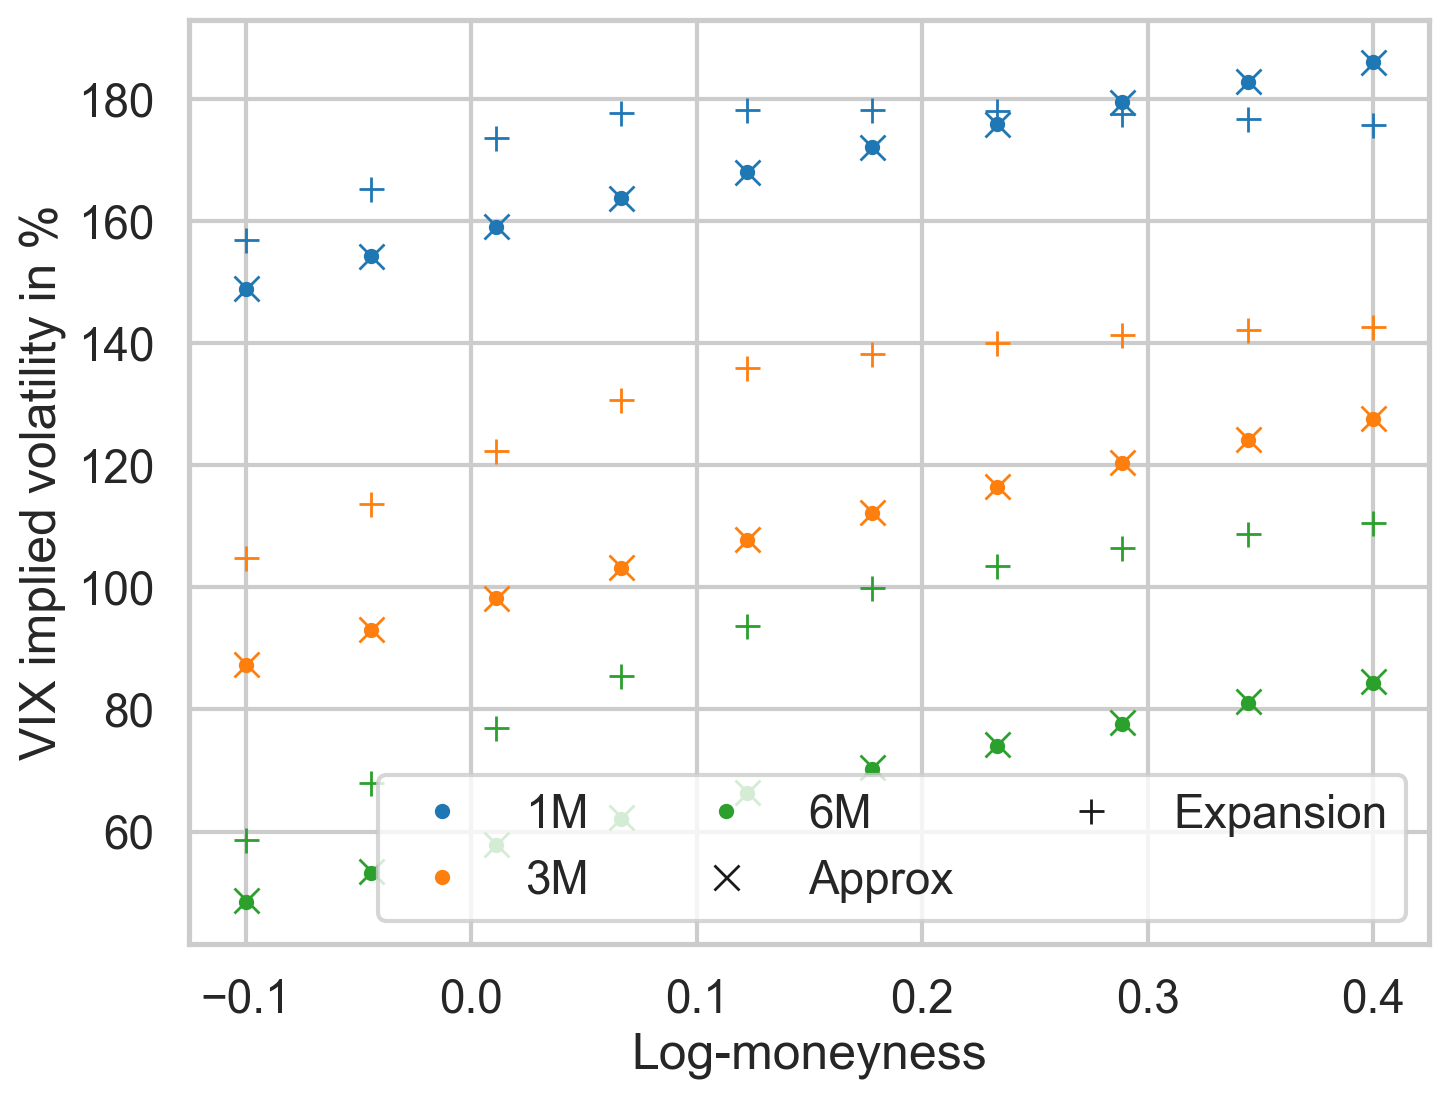

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, month in enumerate(mats.keys()):
    # True VIX implied volatilities
    ax.plot(
        ks,
        100 * impvol_vix_mixed[month],
        ".",
        color=COLORS[i],
        label=f"{month}",
    )
    # Weak approximation
    ax.plot(
        ks,
        100 * impvol_vix_mixed_approx[month],
        "x",
        color=COLORS[i],
    )
    # Expansion formula
    ax.plot(
        ks,
        100 * implied_vol_vix_expansion[month],
        "+",
        color=COLORS[i],
    )
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(ncol=3)
if SAVEFIG:
    fig.savefig(
        f"figures/vix_one_bergomi_mixed_{id}_j_{j_mixed}.pdf", bbox_inches="tight"
    )
plt.show()

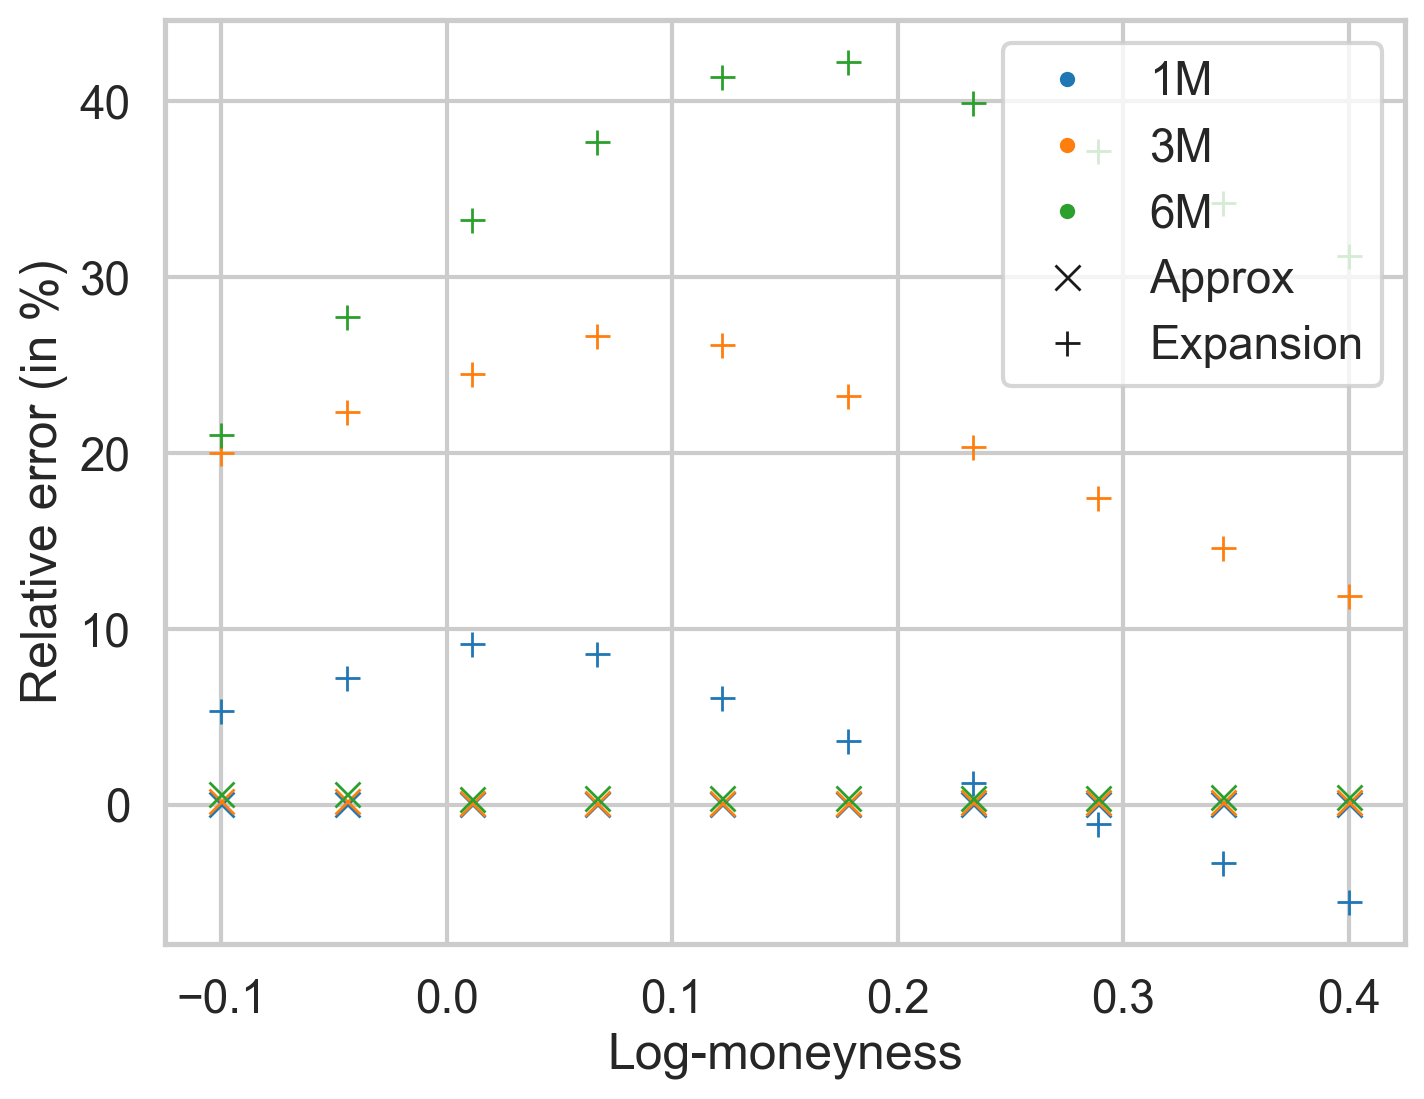

In [23]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_mixed[month], impvol_vix_mixed_approx[month])
    for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_mixed[month], implied_vol_vix_expansion[month])
    for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 1e2 * rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, 1e2 * rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Relative error (in %)")
ax.legend(loc="best")
if SAVEFIG:
    fig.savefig(
        f"figures/vix_one_bergomi_error_mixed{id}_j_{j_mixed}.pdf", bbox_inches="tight"
    )
plt.show()

In [27]:
# Plot from calibration - weak approx paper
ks = np.linspace(-0.2, 0.6, 10)

In [28]:
mats = [1 / 12, 2 / 12, 3 / 12, 4 / 12]
list_id = [3, 4, 5, 6]


params, xi0, lbd, w_2 = get_params_one_bergomi(id=id, opt="mixed")
onebergomi = OneFactorBergomiModel(xi0=xi0, params=params)

impvol_vix_mixed = {}
impvol_vix_mixed_approx = {}
implied_vol_vix_expansion = {}

for i, id in enumerate(list_id):
    params, xi0, lbd, w_2 = get_params_one_bergomi(id=id, opt="mixed")
    onebergomi = OneFactorBergomiModel(xi0=xi0, params=params)
    impvol_vix_mixed[i] = onebergomi.implied_vol_vix(
        k=ks, T=mats[i], n_quad=n_quad, lbd=lbd, w_2=w_2
    )
    impvol_vix_mixed_approx[i] = onebergomi.implied_vol_vix_approx_mixed(
        lbd=lbd, volvol_2=w_2, k=ks, T=mats[i], order=3, n_quad=n_quad
    )
    implied_vol_vix_expansion[i] = np.asarray(
        [
            onebergomi.implied_vol_vix_expansion_mixed(
                k=k, T=mats[i], lbd=lbd, volvol_2=w_2, n_quad=n_quad, n_trunc_herm=10
            )
            for k in ks
        ]
    )

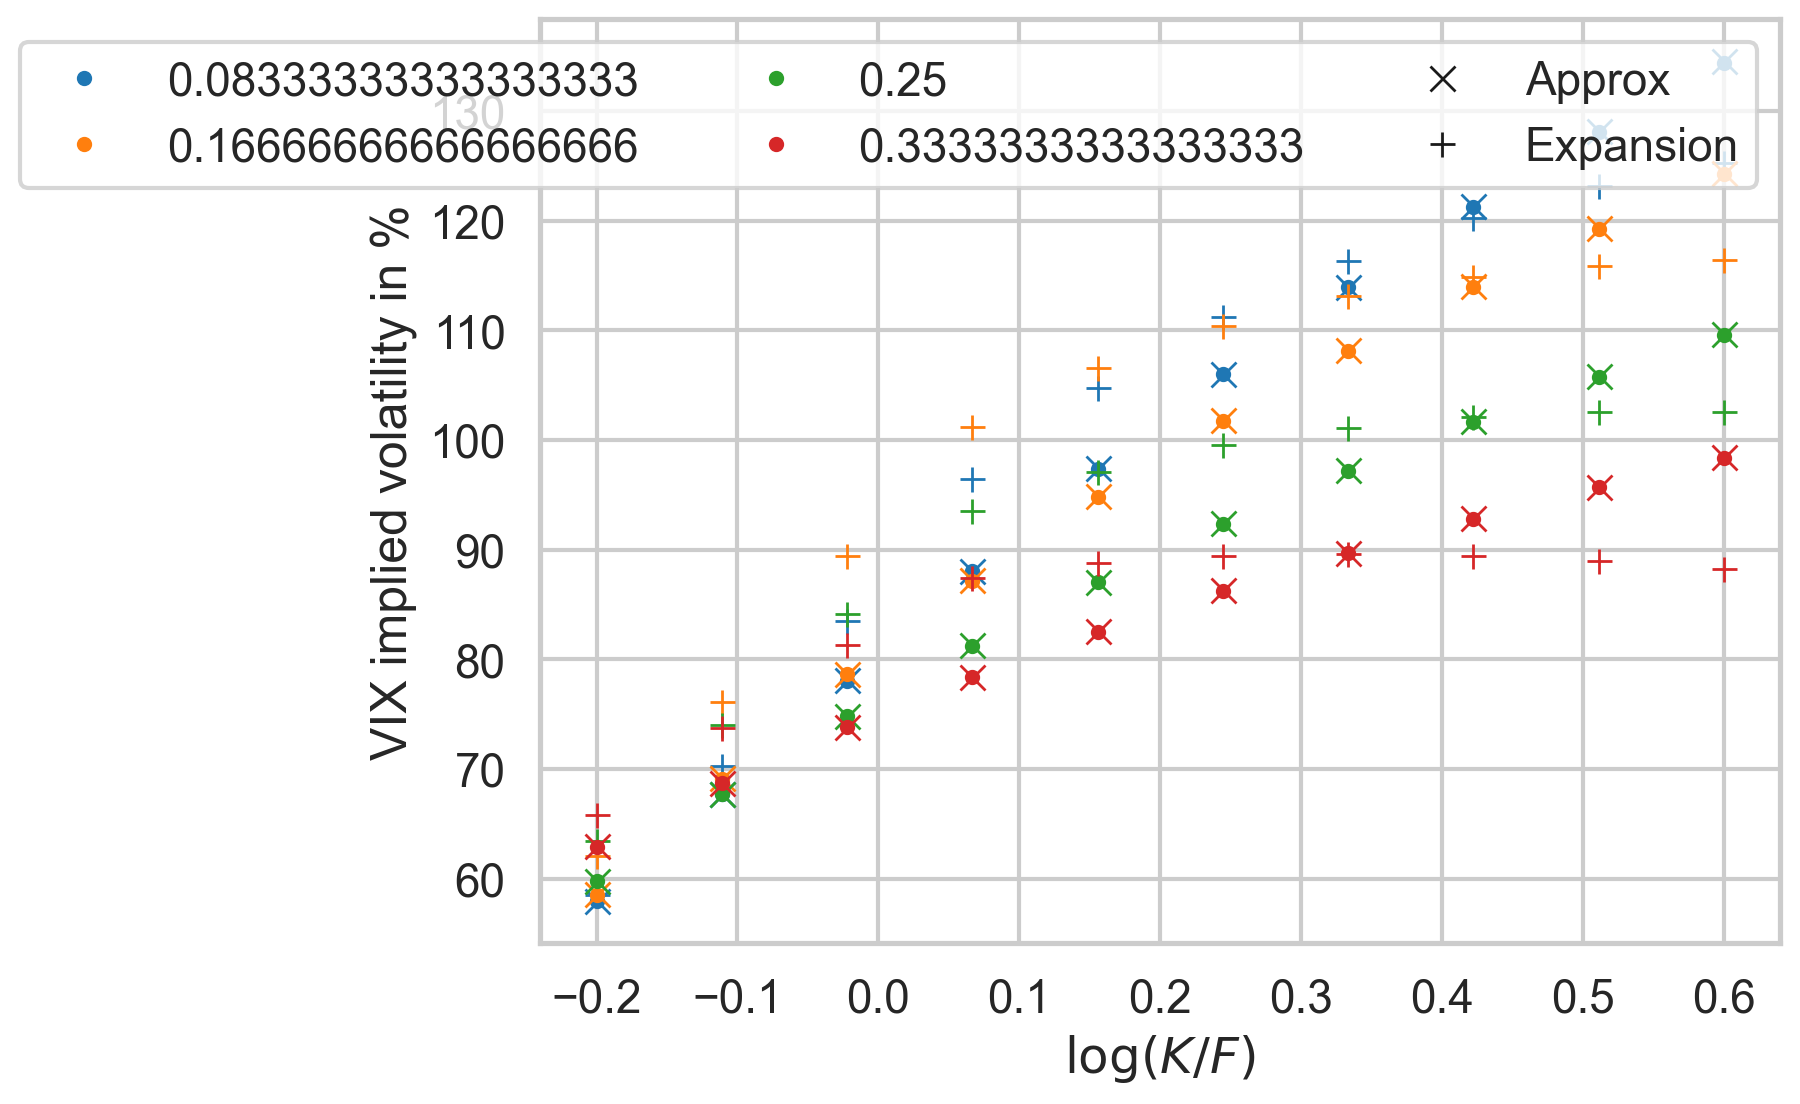

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, month in enumerate(mats[:]):
    # True VIX implied volatilities
    ax.plot(
        ks,
        100 * impvol_vix_mixed[i],
        ".",
        color=COLORS[i],
        label=f"{month}",
    )
    # Weak approximation
    ax.plot(
        ks,
        100 * impvol_vix_mixed_approx[i],
        "x",
        color=COLORS[i],
    )
    # Expansion formula
    ax.plot(
        ks,
        100 * implied_vol_vix_expansion[i],
        "+",
        color=COLORS[i],
    )
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(ncol=3)
# ax.set_ylim(70, 150)
plt.show()